### Using the MobileNetV2 model on a simple dogs vs cats dataset 

##### Importing the dependencies

In [1]:
import os
import numpy as np
from PIL import Image
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
import cv2
import glob 
import warnings
warnings.filterwarnings("ignore")

##### Display the iamge of dog and cat

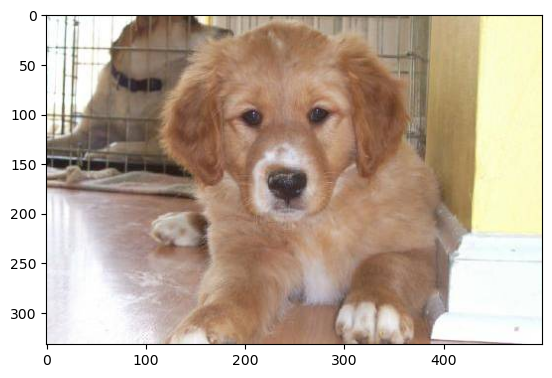

In [2]:
img = mpimg.imread("./Dataset/train/dog.12464.jpg")
plt.imshow(img)


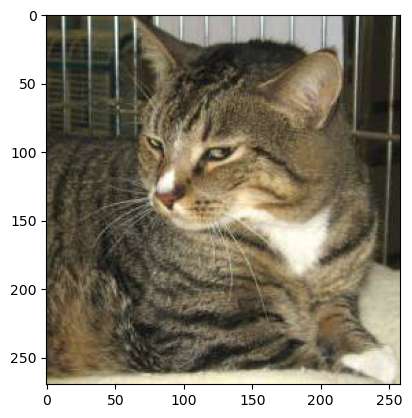

In [3]:
img = mpimg.imread("./Dataset/train/cat.213.jpg")
plt.imshow(img)

#### Resizing all the images

In [4]:
os.mkdir("./Dataset/train_resized")

In [5]:
original_folder = "./Dataset/train/"
resized_folder = "./Dataset/train_resized/"
num_samples = 10000

filename = os.listdir(original_folder)

sampled_filenames = random.sample(filename, num_samples)

for filename in sampled_filenames:
    img_path = original_folder + filename

    img = Image.open(img_path)
    img = img.resize((224,224))
    img = img.convert('RGB')

    newImg_path = resized_folder + filename
    img.save(newImg_path)

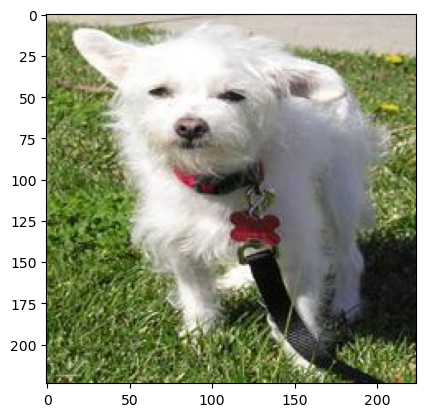

In [7]:
img = mpimg.imread("./Dataset/train_resized/dog.12499.jpg")
plt.imshow(img)

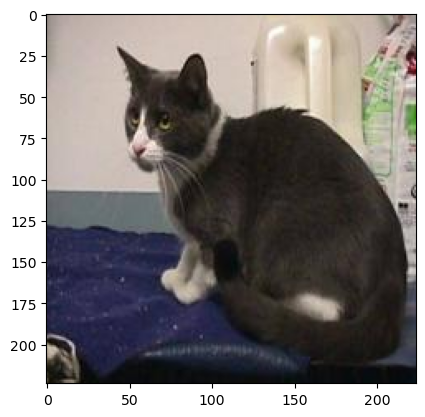

In [8]:
img = mpimg.imread("./Dataset/train_resized/cat.4.jpg")
plt.imshow(img)

##### Creating labels for resized image of dogs and cats
###### Cat --> 0
###### Dog --> 1

In [9]:
filenames = os.listdir("./Dataset/train_resized/")

labels = []

for i in range(10000):
    file_name = filenames[i]
    label = file_name[0:3]

    if label == "dog":
        labels.append(1)

    else:
        labels.append(0)

In [10]:
labels[0:5]

[1, 1, 0, 1, 0]

In [11]:
print(len(labels))

10000


In [12]:
# Counting the images of dogs and cats out of 2000 images
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[4992 5008]


##### Converting all the resized images to numpy arrays

In [13]:
image_directory = "./Dataset/train_resized/"
image_extension = ['png', 'jpg', 'jpeg'] # If we have different image formats in our dataset

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [14]:
dog_cat_images

array([[[[ 52,  35,  26],
         [ 42,  25,  16],
         [ 49,  33,  21],
         ...,
         [228, 189, 161],
         [228, 191, 165],
         [229, 192, 166]],

        [[ 48,  31,  22],
         [ 38,  21,  12],
         [ 44,  28,  16],
         ...,
         [229, 190, 162],
         [229, 192, 166],
         [230, 193, 167]],

        [[ 44,  27,  18],
         [ 35,  18,   9],
         [ 43,  25,  14],
         ...,
         [228, 189, 161],
         [229, 192, 166],
         [230, 193, 167]],

        ...,

        [[ 60,  31,  26],
         [ 64,  36,  29],
         [ 66,  40,  34],
         ...,
         [ 82,  56,  40],
         [ 82,  56,  40],
         [ 82,  56,  40]],

        [[ 61,  32,  28],
         [ 62,  33,  28],
         [ 62,  35,  31],
         ...,
         [ 82,  56,  40],
         [ 82,  56,  40],
         [ 82,  56,  40]],

        [[ 61,  32,  28],
         [ 58,  29,  25],
         [ 55,  28,  24],
         ...,
         [ 82,  56,  40],
        

In [15]:
dog_cat_images.shape

(10000, 224, 224, 3)

In [16]:
X = dog_cat_images
y = np.asarray(labels)

##### Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
X_train.shape, X_test.shape

((8000, 224, 224, 3), (2000, 224, 224, 3))

In [19]:
# Scaling the data
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [20]:
X_train_scaled

array([[[[1.        , 1.        , 0.97647059],
         [0.99215686, 0.99607843, 0.96078431],
         [0.96862745, 0.97647059, 0.95294118],
         ...,
         [0.36078431, 0.4       , 0.51764706],
         [0.35686275, 0.39607843, 0.51372549],
         [0.35686275, 0.39607843, 0.51372549]],

        [[1.        , 0.99607843, 0.96470588],
         [0.99607843, 1.        , 0.96470588],
         [0.99215686, 1.        , 0.97647059],
         ...,
         [0.34901961, 0.38823529, 0.50588235],
         [0.34901961, 0.38823529, 0.50588235],
         [0.34901961, 0.38823529, 0.50588235]],

        [[1.        , 0.99607843, 0.97647059],
         [1.        , 1.        , 0.97647059],
         [1.        , 1.        , 0.98823529],
         ...,
         [0.35294118, 0.39215686, 0.50980392],
         [0.35294118, 0.39215686, 0.50980392],
         [0.34901961, 0.38823529, 0.50588235]],

        ...,

        [[0.28235294, 0.34901961, 0.31372549],
         [0.23921569, 0.30588235, 0.27058824]

##### Building Neural Network

In [21]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
pretrained_model = MobileNetV2(weights='imagenet', include_top=False)

2025-07-05 22:27:52.323436: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2025-07-05 22:27:52.323499: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-07-05 22:27:52.323512: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-07-05 22:27:52.323623: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-07-05 22:27:52.323854: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [28]:
num_of_classes = 2

model = tf.keras.Sequential([

    pretrained_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, None, None, 1280   2257984   
 tional)                     )                                   
                                                                 
 global_average_pooling2d_2  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_4 (Dropout)         (None, 1280)              0         
                                                                 
 dense_4 (Dense)             (None, 128)               163968    
                                                                 
 dropout_5 (Dropout)         (None, 128)               0         
                                                                 
 dense_5 (Dense)             (None, 1)                

In [29]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [30]:
model.fit(X_train_scaled, y_train, epochs=5)

Epoch 1/5


2025-07-05 22:50:08.513293: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


250/250 [==============================] - 61s 214ms/step - loss: 0.2459 - accuracy: 0.8995
Epoch 2/5
250/250 [==============================] - 53s 210ms/step - loss: 0.2539 - accuracy: 0.9018
Epoch 3/5
250/250 [==============================] - 53s 212ms/step - loss: 0.2989 - accuracy: 0.8795
Epoch 4/5
250/250 [==============================] - 54s 218ms/step - loss: 0.4081 - accuracy: 0.8265
Epoch 5/5
250/250 [==============================] - 55s 218ms/step - loss: 0.4945 - accuracy: 0.7797


In [31]:
score, acc = model.evaluate(X_test_scaled, y_test)
print('Test loss: ', score)
print(f'Test accuracy: {acc * 100: .2f}')

63/63 [==============================] - 7s 92ms/step - loss: 1.9720 - accuracy: 0.5070
Test loss:  1.9720324277877808
Test accuracy:  50.70


##### Predictive System

1/1 [==============================] - 0s 32ms/step
The image is of a cat


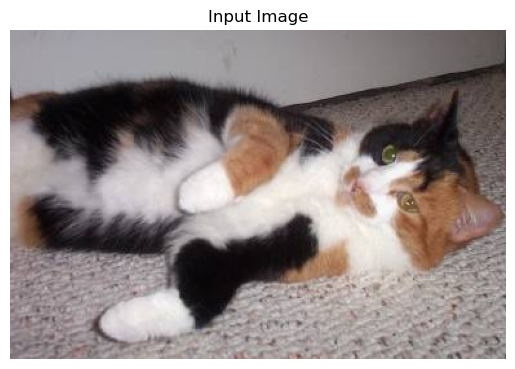

In [33]:
input_image_path = input('Path of the image to be predicted: ')
input_image = cv2.imread(input_image_path)
if input_image is None:
    print("Error: Could not read the image. Check the path!")
else:
    plt.imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB))
    plt.title('Input Image')
    plt.axis('off')
input_image_resize = cv2.resize(input_image, (224, 224))
input_image_scaled = input_image_resize / 255
input_image_reshaped = np.reshape(input_image_scaled, [1, 224, 224, 3])
input_prediction = model.predict(input_image_reshaped)
input_pred_label = np.argmax(input_prediction)

if input_pred_label == 0:
    print("The image is of a cat")
else:
    print("The image is of a dog")